In [18]:
from pyspark.sql import SparkSession

# Inicializa a sessão Spark
spark = SparkSession.builder \
    .appName("verificacao_duplicatas") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

# Caminho do diretório
PATH_PP = "/home/students/moliveira/telegram-political-toxicity/data/processed/messages_preprocessed/"

# Leitura do formato Parquet (sem precisar declarar o schema!)
df_pp = spark.read.parquet(PATH_PP)

# Selecionamos 'channel_id' no lugar de 'file_path'
#df_pk = df_pp.select("id", "channel_id")

print(f"Total de linhas: {df_pp.count()}")

[Stage 29:=====================================================>(205 + 1) / 206]

Total de linhas: 48425268


In [19]:
df_pp.columns

['id',
 'group_name',
 'text',
 'timestamp',
 'file_path',
 'text_clean',
 'datetime',
 'language',
 'date_type',
 'clean_text',
 'year',
 'month']

In [20]:
df_pk = df_pp.select("id", "group_name").distinct()

print(f"Total de linhas únicas: {df_pk.count():,}")

[Stage 34:==================================================>     (61 + 6) / 67]

Total de linhas únicas: 48,425,268


In [21]:
df_pp.show()

+------+------------------+--------------------+----------+--------------------+--------------------+-------------------+--------+-------------------+--------------------+----+-----+
|    id|        group_name|                text| timestamp|           file_path|          text_clean|           datetime|language|          date_type|          clean_text|year|month|
+------+------------------+--------------------+----------+--------------------+--------------------+-------------------+--------+-------------------+--------------------+----+-----+
|973700|channel_2011252634|youtube ($youtube...|1722576213|file:///home/stud...|youtube ($youtube...|2024-08-02 05:23:33|      en|2024-08-02 05:23:33|youtube youtube c...|2024|    8|
|973803|channel_2011252634|BOOGA ($BOOG)\n\n...|1722578535|file:///home/stud...|BOOGA ($BOOG)\n\n...|2024-08-02 06:02:15|      en|2024-08-02 06:02:15|booga boog jczapz...|2024|    8|
|966122|channel_2011252634|Jenx ($JENX)\n\n?...|1722521420|file:///home/stud...|Jenx 

In [22]:
!pip install matplotlib

Calculando volume de mensagens por mês no Spark...


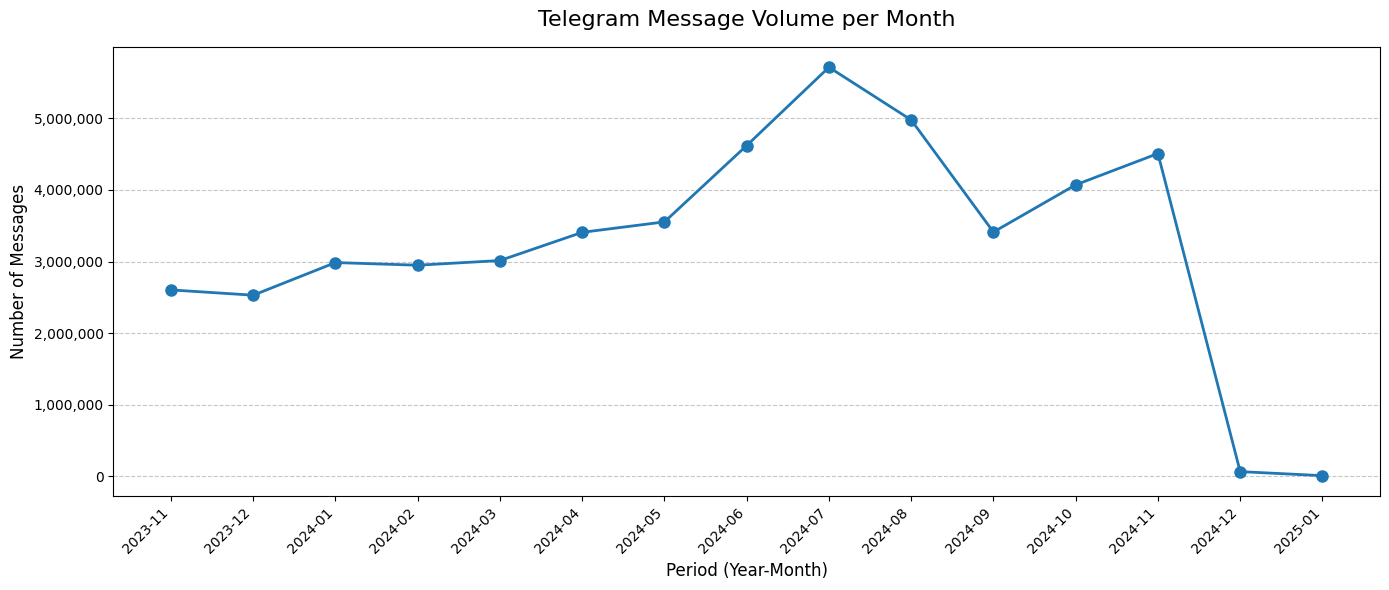

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import pyspark.sql.functions as F

print("Calculando volume de mensagens por mês no Spark...")

# 1. Agrupa e conta os dados usando o processamento pesado do Spark
df_agrupado = (
    df_pp.filter(F.col("year").isNotNull() & F.col("month").isNotNull()) # Remove datas inválidas
    .groupBy("year", "month")
    .count()
    .orderBy("year", "month")
)

# 2. Traz o resultado resumido (poucas linhas) para a RAM do Notebook via Pandas
df_pd = df_agrupado.toPandas()

# 3. Prepara os dados para o gráfico (Cria uma coluna no formato "YYYY-MM")
df_pd['periodo'] = df_pd['year'].astype(int).astype(str) + '-' + df_pd['month'].astype(int).astype(str).str.zfill(2)

# 4. Plota o gráfico com Matplotlib
plt.figure(figsize=(14, 6)) # Define o tamanho da imagem

# Linha principal
plt.plot(df_pd['periodo'], df_pd['count'], marker='o', linewidth=2, markersize=8, color='#1f77b4')

# Estética do gráfico
plt.title("Telegram Message Volume per Month", fontsize=16, pad=15)
plt.xlabel("Period (Year-Month)", fontsize=12)
plt.ylabel("Number of Messages", fontsize=12)

# Rotaciona os textos do eixo X para não ficarem encavalados
plt.xticks(rotation=45, ha='right')

# Formata o eixo Y para mostrar números com separador de milhar (ex: 1.500.000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Adiciona uma grade de fundo para facilitar a leitura
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Ajusta as margens automaticamente
plt.show()